In [1]:
import jax.random as jrand
import jax.numpy as jnp
from jax.scipy.signal import convolve2d
rng_key = jrand.PRNGKey(5)

In [2]:
rng_key, subkey = jrand.split(rng_key)
arm_density = 0.05  # Average number of arms per person
population_density = 5e4  # Average number of people per grid cell
walk_radius = 30  # Number of steps in the random walk
atrisk_gathering_rate = 0.001  # Rate of gatherings per population encounter
mix_perc = 0.5  # Percentage chance of mixing optimal and base states

pgrid = (jrand.uniform(rng_key, (30, 30)) > 0.95).astype(jnp.float32)
#Use jax to convolve population_grid with a 7x7 gaussian kernel to create pgrid
kernel = jnp.arange(-4, 5)
kernel = jnp.exp(-0.5 * (kernel / 2.5) ** 2)
kernel = kernel / jnp.sum(kernel)
kernel = jnp.outer(kernel, kernel)
pgrid = convolve2d(pgrid, kernel, mode='same')
pgrid = pgrid / jnp.max(pgrid)
population_grid = pgrid * population_density

flat_pop_grid = population_grid.flatten()
probabilities = flat_pop_grid / jnp.sum(flat_pop_grid)

rng_key, subkey = jrand.split(rng_key)

max_access = 1
access_points = jrand.choice(subkey, population_grid.size, (max_access+1,), p=probabilities)

total_lambda = arm_density * population_grid.size
access_grid = pgrid / pgrid.sum() * total_lambda
access_grid = jrand.poisson(subkey, lam=access_grid)

rng_key, subkey = jrand.split(rng_key)
start_pos_r, start_pos_c = jnp.unravel_index(access_points[-1], population_grid.shape)
random_walk = jrand.randint(subkey, (100, 2), -1, 2)
random_walk = (jnp.cumsum(random_walk, axis=0) + jnp.array([start_pos_r, start_pos_c])) % population_grid.shape[0]
walk_mask = jnp.arange(100) < walk_radius

weapon_rolls = jnp.sum(access_grid[random_walk[:, 0], random_walk[:, 1]]*walk_mask)
weapon_access = (weapon_rolls > 0)
rng_key, subkey = jrand.split(rng_key)
high_weapon_access = jrand.bernoulli(subkey, p=1 - jnp.exp(-0.1 * weapon_rolls)) #Assume each weapon has a 10% chance of being high powered

population_encounters = jnp.sum(population_grid[random_walk[:, 0], random_walk[:, 1]]*walk_mask)

rng_key, s1, s2 = jrand.split(rng_key, 3)
location_count = jrand.poisson(s1, lam=population_encounters * atrisk_gathering_rate + 1)
# base_location_count = jrand.poisson(s2, lam=(population_grid[start_pos_r, start_pos_c] * atrisk_gathering_rate + 1))

rng_key, subkey = jrand.split(rng_key)
max_location = 250
location_mask = jnp.arange(max_location+5) < location_count
loc_gathering_size = jrand.weibull_min(subkey, 2, 0.4, (max_location+5,))
max_gathering_size = jnp.max(loc_gathering_size*location_mask, initial=0)

base_gathering_size = loc_gathering_size[max_location]
base_weapon_access = access_grid[start_pos_r, start_pos_c] > 0

rng_key, subkey = jrand.split(rng_key)
base_high_weapon_access = jrand.bernoulli(subkey, p=1 - jnp.exp(-0.1)) & base_weapon_access

rng_key, subkey = jrand.split(rng_key)
opt_state = jrand.bernoulli(subkey, p=mix_perc)

gathering_size = jnp.where(opt_state, max_gathering_size, base_gathering_size)
weapon_access = jnp.where(opt_state, weapon_access, base_weapon_access)
high_weapon_access = jnp.where(opt_state, high_weapon_access, base_high_weapon_access)
# location_count = jnp.where(opt_state, location_count, base_location_count)

expon_lambda = 6 + 120 * high_weapon_access
rng_key, subkey = jrand.split(rng_key)
fatalities = jnp.remainder(jrand.exponential(subkey, shape=()) * expon_lambda, gathering_size)
# return (weapon_access & (location_count > 0)) * fatalities #, opt_state, location_count, gathering_size, weapon_access, high_weapon_access, base_high_weapon_access

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle

population_grid_np = np.array(population_grid)
access_grid_np = np.array(access_grid)
random_walk_np = np.array(random_walk)
walk_mask_np = np.array(walk_mask)
start_pos = (int(start_pos_r), int(start_pos_c))

fig, ax = plt.subplots(1, 1, figsize=(14, 12))

im = ax.imshow(population_grid_np, cmap='YlOrRd', alpha=0.8)
# cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
# cbar.set_label('Population per Cell', rotation=270, labelpad=20, fontsize=12)

# Overlay: Weapon locations as red circles
weapon_locs = np.argwhere(access_grid_np > 0)
weapon_counts = access_grid_np[access_grid_np > 0]
weapon_sizes = weapon_counts * 30 + 20  # Scale circle size by weapon count

ax.scatter(weapon_locs[:, 1], weapon_locs[:, 0], s=weapon_sizes*5, 
          c='darkred', alpha=0.7, edgecolors='white', linewidth=2, 
          label=f'Weapons Access', zorder=3, marker='o')

# Plot the active part of the random walk
active_walk = random_walk_np[walk_mask_np]

# Draw the walk path with gradient color
for i in range(len(active_walk) - 1):
    ax.plot([active_walk[i, 1], active_walk[i+1, 1]], 
            [active_walk[i, 0], active_walk[i+1, 0]], 
            color='white', linewidth=3, alpha=0.9, zorder=5)

ax.plot(active_walk[0, 1], active_walk[0, 0], 'g*', markersize=30, markeredgecolor='black', 
        markeredgewidth=2.5, label='Start Position', zorder=10)

# ax.plot(active_walk[-1, 1], active_walk[-1, 0], 'r', markersize=30, 
#         markeredgecolor='black', markeredgewidth=2.5, label='End Position', zorder=10)

# Mark weapon encounters along the walk
weapon_encounters = []
for step in active_walk:
    if access_grid_np[step[0], step[1]] > 0:
        weapon_encounters.append(step)

if weapon_encounters:
    weapon_encounters = np.array(weapon_encounters)
    ax.scatter(weapon_encounters[:, 1], weapon_encounters[:, 0], 
               marker='X', s=300, c='yellow', edgecolors='black', linewidth=2.5, 
               label='Weapon Encounter', zorder=8)

# ax.set_title('Agent-Based Model: Population, Weapons, and Random Walk\n' + 
#             f'Walk: {int(walk_radius)} steps | Weapons Found: {int(weapon_rolls)} | ' +
#             f'Fatalities: {float(fatalities):.1f}',
#             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Position (miles)', fontsize=12)
ax.set_ylabel('Position (miles)', fontsize=12)


handles, labels = ax.get_legend_handles_labels()

# Add a patch for population density
import matplotlib.patches as mpatches
from matplotlib import cm
cmap = cm.get_cmap('YlOrRd')
patch = mpatches.Patch(color=cmap(0.7), label='Population density')

handles.append(patch)
labels.append('Population density')

# --- Display legend ---
ax.legend(handles, labels, loc='lower left', frameon=True, borderpad=1, labelspacing=2.5, framealpha=0.6, fontsize=24, edgecolor='black')
# ax.legend(loc='upper left', fontsize=11, framealpha=0.95, edgecolor='black')
# ax.grid(True, alpha=0.3, linestyle='--', color='gray')

plt.tight_layout()
plt.savefig('/home/andrew/abm_violence/paper_code/images/abm_merged_visualization.png', 
            dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1618556/1707917378.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlOrRd')


In [12]:
import rasterio
import numpy as np

# 1. Open the GeoTIFF file
data_dir = '/home/andrew/abm_violence/data/'
with rasterio.open(data_dir + 'populationdensity_mappackage/usa_pd_2020_1km_UNadj.tif') as dataset:
    population_array = dataset.read(1)

    print(f"Data shape: {population_array.shape}")
    print(f"Data type: {population_array.dtype}")
    
    max_density = np.max(population_array)
    print(f"Maximum density found: {max_density} people per pixel")

    # You can also get all the geographic metadata
    print(f"Coordinate Reference System (CRS): {dataset.crs}")
    print(f"Geographic Bounds: {dataset.bounds}")
population_array = population_array[2000:, 6500:13500]

Data shape: (6298, 43072)
Data type: float32
Maximum density found: 64591.2734375 people per pixel
Coordinate Reference System (CRS): EPSG:4326
Geographic Bounds: BoundingBox(left=-179.15124930330558, bottom=18.90791676654655, right=179.78208259429442, top=71.39124988994655)


In [ ]:
import rasterio
import numpy as np
import plotly.express as px

data_dir = '/home/andrew/abm_violence/data/'
with rasterio.open(data_dir + 'populationdensity_mappackage/usa_pd_2020_1km_UNadj.tif') as dataset:
    population_array = dataset.read(1).astype(float)
    transform = dataset.transform

# Optional crop (as you already did)
population_array = population_array[2000:, 6500:13500]

# Replace no-data values with NaN
population_array[population_array <= 0] = np.nan

# Compute the coordinate grid
rows, cols = population_array.shape
x_coords = np.arange(cols) * transform.a + transform.c
y_coords = np.arange(rows) * transform.e + transform.f

# Plotly expects 2D data with explicit coordinates
fig = px.imshow(
    population_array,
    origin='upper',
    x=x_coords,
    y=y_coords,
    color_continuous_scale='viridis',
    title='Population Density (people per km²)',
)

fig.update_xaxes(title='Longitude')
fig.update_yaxes(title='Latitude')
fig.show()

In [53]:
print(extent)

import matplotlib.pyplot as plt
import rasterio

data_dir = '/home/andrew/abm_violence/data/'
with rasterio.open(data_dir + 'populationdensity_mappackage/usa_pd_2020_1km_UNadj.tif') as dataset:
    population_array = dataset.read(1).astype(float)
    bounds = dataset.bounds
# population_array = population_array[2000:, 6500:13500]
population_array[population_array <= 0] = np.nan

# population_array = population_array[bottom_ind:top_ind, left_ind:right_ind]
# bounds = usa_bounds
print(bounds)


[-125, -66.5, 24, 55]
BoundingBox(left=-179.15124930330558, bottom=18.90791676654655, right=179.78208259429442, top=71.39124988994655)
BoundingBox(left=-179.15124930330558, bottom=18.90791676654655, right=179.78208259429442, top=71.39124988994655)


In [55]:
population_array.shape
usa_bounds = [-125, -66.5, 24, 55]  # [left, right, bottom, top]
slng, elng = bounds.left, bounds.right
slat, elat = bounds.bottom, bounds.top

In [56]:
left_ind = int((usa_bounds[0] - slng) / (elng - slng) * population_array.shape[1])
right_ind = int((usa_bounds[1] - slng) / (elng - slng) * population_array.shape[1])
bottom_ind = population_array.shape[0] - int((usa_bounds[2] - slat) / (elat - slat) * population_array.shape[0])
top_ind = population_array.shape[0] - int((usa_bounds[3] - slat) / (elat - slat) * population_array.shape[0])

print(left_ind, right_ind, bottom_ind, top_ind)
sub_arr = population_array[top_ind:bottom_ind, left_ind:right_ind]

6498 13518 5687 1967


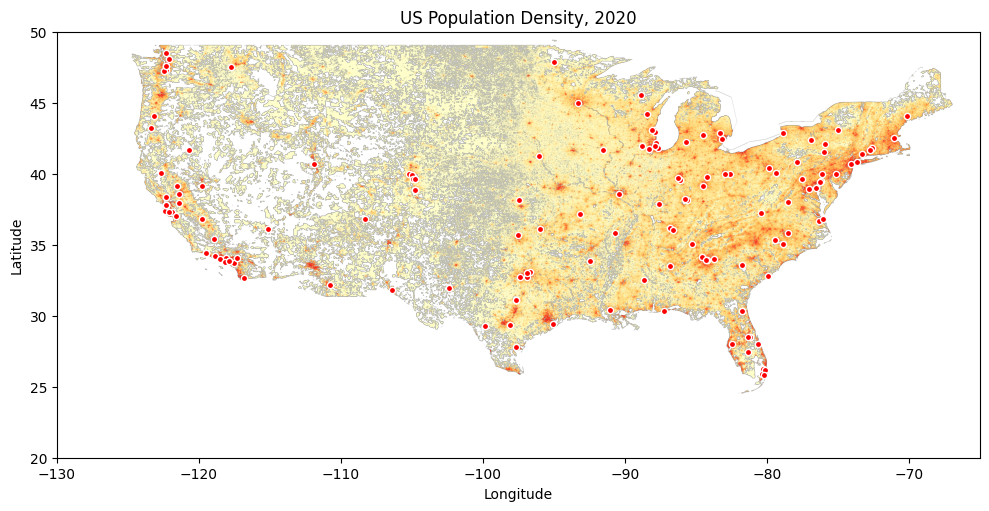

In [ ]:
extent = usa_bounds

plt.figure(figsize=(10, 10))
plt.imshow(sub_arr, extent=extent, cmap='YlOrRd', origin='upper', 
           norm=LogNorm(vmin=1, vmax=np.nanmax(population_array)))

data_dir = "/home/andrew/abm_violence/data/"
import pandas as pd
pop_density_df = pd.read_csv(data_dir + "processed/city_population_density.csv")
event_df = pd.read_csv(data_dir + "processed/event_data.csv")
event_df = pd.merge(event_df, pop_density_df[['GISJOIN', 'lat', 'lng']], 
                    left_on="GISID", right_on="GISJOIN")

event_lat = event_df['lat'].values
event_lng = event_df['lng'].values

pop_density_df['pop_density'] = pop_density_df['CL8AA2020_density']
pop_density_df['log_pop_density'] = np.log1p(pop_density_df['pop_density'])

plt.scatter(event_lng, event_lat, c='red', s=20, label='Sample locations', edgecolor='white')

# plt.colorbar(label='People per km²')
plt.title('US Population Density, 2020')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(-130, -65)
plt.ylim(20, 50)
plt.tight_layout()

plt.savefig('/home/andrew/abm_violence/paper_code/images/country_density_map.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Alternative visualization: Scatter map with population as background
fig2 = go.Figure()

sample_pop = pop_density_df.sample(n=min(5000, len(pop_density_df)))  # Sample for performance
fig2.add_trace(go.Scattermap(
    lat=sample_pop['lat'],
    lon=sample_pop['lng'],
    mode='markers',
    marker=dict(
        size=4,
        color=sample_pop['log_pop_density'],
        colorscale='YlOrRd',
        opacity=0.3,
        colorbar=dict(
            title="Log Pop<br>Density",
            x=1.02
        )
    ),
    name='Population Density',
    showlegend=False,
))

fig2.update_layout(
        title = 'USA Population Density',
        geo_scope='usa',
    )
fig2.show()

In [3]:
from gvabm.city_data import city_data

In [7]:
city_data_l = [city_data[city_id]['params'].arm_density for city_id in city_data]

In [11]:
arm_density_l = [city_data['params'].arm_density for city_id, city_data in city_data.items()]
import numpy as np
max_ind = np.argmax(np.array(arm_density_l))
max_city_id = list(city_data.keys())[max_ind]
print(f"City with highest arm density: {max_city_id} with density {arm_density_l[max_ind]}")
print(city_data[max_city_id])

City with highest arm density: ('G040013092601', 1990) with density 0.523312101910828
{'events': [], 'params': CityParams(year=1990, population=1932166.85, population_density=686.6876285695334, arm_count=1027.0, arm_density=0.523312101910828), 'name': ('Arizona', 'Maricopa County')}


In [16]:
px.density_map(pop_density_df, lat='lat', lon='lng', z='pop_density',
               radius=50, center=dict(lat=39.8283, lon=-98.579), zoom=2, )


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(data_dir + "ffl_list.txt", sep="\t")
zips = pd.read_csv(data_dir + "2013_us_zips.csv")
df = df[df["LIC_TYPE"].isin([1, 2, 7])]
df = df[["MAIL_ZIP_CODE", "LICENSE_NAME"]].merge(right= zips, left_on="MAIL_ZIP_CODE", right_on="ZIP").drop(columns="ZIP")

f = df.groupby("MAIL_ZIP_CODE").agg("first")
df = df.groupby("MAIL_ZIP_CODE").agg("count")[["LAT"]].rename(columns={"LAT":"count"})
df = df.merge(f, right_index=True, left_index=True)
df["count"] = np.log(df["count"])
# df.head()